# 05b - Task 3: Hyperparameter tuning (LogReg Ridge)

Parallel variant of 05_tuning.ipynb's search - same pipeline (same src/tuning.py
mechanism, same locked CV, same OWNER-tagged resumable/mergeable trial files), applied
to LogReg Ridge instead of LightGBM.

Carried forward as a hedge against the train-to-test distribution shift: LightGBM's
Kaggle score (0.65738) came in well below its CV/holdout estimate (~0.744). A linear
model may generalize differently under that shift than a second boosted-tree model
would, since it's a genuinely different algorithm family, not just a different
configuration of the same one.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from scipy.stats import loguniform
from sklearn.model_selection import ParameterSampler, ParameterGrid
from sklearn.linear_model import LogisticRegression

from src import paths, data, evaluation, tuning
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features + the locked split

In [2]:
X, y, ids = data.load_train_features()
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

X_dev, y_dev = X[dev_idx], y[dev_idx]

In [3]:
# Edit this before running your own portion of the search - it tags every trial file
# you produce, so your results are distinguishable from teammates' and nothing gets
# silently overwritten when files are merged (e.g. via git pull).
OWNER = "solo_demo"  # e.g. "alice_c_lo" for a named sub-range, see section 2

## 2. Search space - what each knob does and why this range

Tuning LogReg Ridge, carried forward from 04_models.ipynb (baseline F1 0.7246) as a
hedge against the train-to-test distribution shift observed on Kaggle. Fixed from that
baseline: `penalty="l2", solver="lbfgs", max_iter=2000, random_state=42`. Knobs searched
here, and why:

- `C` (log-uniform, 0.001-100): inverse regularization strength, the one hyperparameter
  that actually moves a Ridge-penalized linear model's decision boundary. Baseline used
  the sklearn default (C=1.0, implicit); this searches several orders of magnitude
  around it since the right amount of regularization for 5000 sparse features on a
  16000-row dev set isn't obvious a priori.
- `class_weight` (categorical, "balanced" vs `None`): the baseline sweep assumed
  `class_weight="balanced"` helps given the 62.5/37.5 class skew, but that assumption
  was never itself tested head-to-head - included here as a cheap, genuine check rather
  than carrying it forward unverified.

Much smaller search space than LightGBM's (2 knobs vs 7), since Ridge-penalized
logistic regression only has one hyperparameter with real effect on the decision
boundary. Sub-range for team splitting: split by `C` order-of-magnitude band (e.g. one
person covers 0.001-0.1, another 0.1-10, another 10-100) - record which band in the
`OWNER` string above.

## 3. Stage 1 - coarse search

Draws random combinations from the distributions above and scores each one via
`tuning.run_trial` - same resumable/mergeable mechanism as 05_tuning.ipynb.

In [4]:
param_dist = {
    "C": loguniform(0.001, 100),
    "class_weight": ["balanced", None],
}

N_ITER = 8
sampler = ParameterSampler(param_dist, n_iter=N_ITER, random_state=42)

for i, params in enumerate(sampler):
    print(f"[{i + 1}/{N_ITER}] {params}")
    est = LogisticRegression(
        penalty="l2", solver="lbfgs", max_iter=2000, random_state=42, **params,
    )
    result = tuning.run_trial("logreg_ridge_stage1", OWNER, est, params, X_dev, y_dev, cv)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")

[1/8] {'C': np.float64(0.0745934328572655), 'class_weight': 'balanced'}


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  mean=0.3847  std=0.0001


## 4. Merge stage-1 results across teammates

Pulls in every stage-1 trial file present on disk - all owners, all sub-ranges. Same
merge step as 05_tuning.ipynb.

In [5]:
stage1_trials = tuning.load_trials("logreg_ridge_stage1")
print(f"{len(stage1_trials)} stage-1 trials merged, from owners: "
      f"{sorted(stage1_trials['owner'].unique())}")
print(stage1_trials[["owner", "params", "mean", "std"]].to_string())

center = stage1_trials.iloc[0]["params"]
print("\nMerged winner, centering stage 2 on:", center)

8 stage-1 trials merged, from owners: ['solo_demo']
       owner                                                  params      mean       std
0  solo_demo   {'C': 0.9846738873614566, 'class_weight': 'balanced'}  0.724338  0.003785
1  solo_demo         {'C': 3.4702669886504163, 'class_weight': None}  0.719133  0.004017
2  solo_demo  {'C': 0.16949768237884735, 'class_weight': 'balanced'}  0.695898  0.006344
3  solo_demo   {'C': 0.0745934328572655, 'class_weight': 'balanced'}  0.675382  0.006098
4  solo_demo        {'C': 0.04661686413912769, 'class_weight': None}  0.397434  0.002413
5  solo_demo      {'C': 0.0019145111285710716, 'class_weight': None}  0.384686  0.000058
6  solo_demo       {'C': 0.008263688714158009, 'class_weight': None}  0.384686  0.000058
7  solo_demo      {'C': 0.0019517224641449498, 'class_weight': None}  0.384686  0.000058

Merged winner, centering stage 2 on: {'C': 0.9846738873614566, 'class_weight': 'balanced'}


## 5. Stage 2 - refined search around the merged winner

Centers a tighter grid on `C` around the merged best trial, still trying both
`class_weight` options (not just the stage-1 winner's) so section 6's heatmap compares
them fairly at the refined C values too.

In [6]:
def band(value, frac, n=3):
    """n points spanning +/- frac around value, always including the exact center,
    clipped to stay positive."""
    lo, hi = value * (1 - frac), value * (1 + frac)
    vals = {value, max(lo, 1e-4), hi}
    return sorted(round(v, 6) for v in vals)


refined_grid = {
    "C": band(center["C"], frac=0.5),
    "class_weight": ["balanced", None],
}
combos = list(ParameterGrid(refined_grid))
print(f"Refined grid: {len(combos)} combinations")

# Kept separate from tuning_trials' full merged history (which can mix slightly
# different grids across reruns) so the heatmap below stays a clean, aligned rectangle.
grid_results = []
for i, params in enumerate(combos):
    print(f"[{i + 1}/{len(combos)}] {params}")
    est = LogisticRegression(
        penalty="l2", solver="lbfgs", max_iter=2000, random_state=42, **params,
    )
    result = tuning.run_trial("logreg_ridge_stage2", OWNER, est, params, X_dev, y_dev, cv)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")
    grid_results.append({"C": params["C"], "class_weight": str(params["class_weight"]),
                          "mean": result["mean"]})

Refined grid: 6 combinations
[1/6] {'C': 0.492337, 'class_weight': 'balanced'}


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  mean=0.7097  std=0.0060


### Visualize the grid search

Heatmap of Macro F1 across the refined `C` x `class_weight` grid.

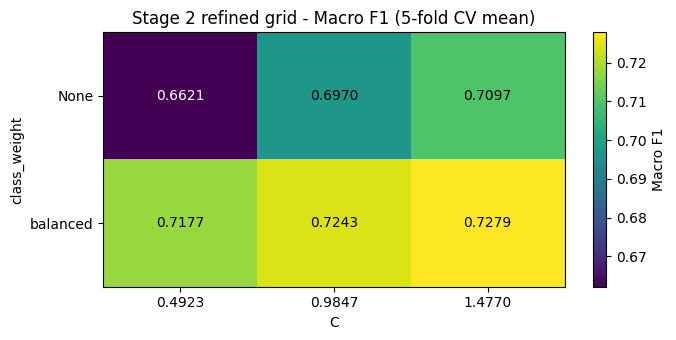

In [7]:
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index="class_weight", columns="C", values="mean")

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.4f}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("C")
ax.set_ylabel("class_weight")
ax.set_title("Stage 2 refined grid - Macro F1 (5-fold CV mean)")

vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
mid = (vmin + vmax) / 2
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                color="white" if val < mid else "black")

fig.colorbar(im, ax=ax, label="Macro F1")
plt.tight_layout()
plt.savefig(FIGURES / "logreg_ridge_stage2_grid_heatmap.png", dpi=120)
plt.show()

## 6. Persist winning params + fitted model

Only the overall winner gets refit and pickled here - not something every teammate
produces, since pickled sklearn objects are version-sensitive across machines.

In [8]:
stage2_trials = tuning.load_trials("logreg_ridge_stage2")

# Select from the COMBINED pool of every trial run, not just stage 2 in isolation -
# same fix applied in 05_tuning.ipynb after a coarser refined grid there failed to beat
# the stage-1 winner; picking from stage 2 alone risks the same silent regression.
all_trials = pd.concat([stage1_trials, stage2_trials], ignore_index=True).sort_values(
    "mean", ascending=False
)
overall_best = all_trials.iloc[0]
best_params = overall_best["params"]
print(f"Best trial across stage 1 ({len(stage1_trials)}) + stage 2 ({len(stage2_trials)}) "
      f"= {len(all_trials)} total trials")
print("Winning params:", best_params)
print(f"Winning Macro F1 (5-fold CV mean): {overall_best['mean']:.4f} (std {overall_best['std']:.4f})")

paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
with open(paths.DATA_PROCESSED / "best_logreg_ridge_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

final_est = LogisticRegression(
    penalty="l2", solver="lbfgs", max_iter=2000, random_state=42, **best_params,
)
final_est.fit(X_dev, y_dev)

paths.MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(final_est, paths.MODELS / "best_logreg_ridge_tuned.pkl")

metadata = {
    "model": "logreg_ridge",
    "params": best_params,
    "cv_mean_f1": overall_best["mean"],
    "cv_std_f1": overall_best["std"],
    "n_stage1_trials": len(stage1_trials),
    "n_stage2_trials": len(stage2_trials),
}
with open(paths.MODELS / "best_logreg_ridge_tuned.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved best_logreg_ridge_params.json, best_logreg_ridge_tuned.pkl, best_logreg_ridge_tuned.json")

Best trial across stage 1 (8) + stage 2 (6) = 14 total trials
Winning params: {'C': 1.477011, 'class_weight': 'balanced'}
Winning Macro F1 (5-fold CV mean): 0.7279 (std 0.0029)


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Saved best_logreg_ridge_params.json, best_logreg_ridge_tuned.pkl, best_logreg_ridge_tuned.json


## Discussion / carry-forward -> `06_holdout.ipynb`

**Result:** C=1.477, class_weight="balanced", Macro F1 0.7279 (std 0.0029) across 14
total trials (8 stage-1 + 6 stage-2). Up from the 04_models baseline (0.7246, sklearn's
default C=1.0) by +0.0033 - a small, real gain from tuning C, similar in size to
LightGBM's own tuning gain (+0.0032). Still well below tuned LightGBM (0.7443, a 0.0164
gap) - consistent with the 04_models finding that gradient boosting has a genuine edge
on this diffuse-signal, high-dimensional TF-IDF data, and tuning a linear model doesn't
close that gap.

**class_weight="balanced" is confirmed necessary, not just assumed.** The heatmap shows
it winning at every C tested. More strikingly: without it, low-C (heavily regularized)
configs collapse to ~0.385 Macro F1 - matching the EDA's computed majority-class-only
floor almost exactly. Unweighted plus strong regularization gives the model no reason
to learn the minority (human) class at all; only at high C (weak regularization) does
unweighted logistic regression recover to something competitive (0.719 at C=3.47),
still short of balanced's 0.724 at a similar C. This validates a decision that was
carried forward from 04_models without being individually tested there.

**Still open:** whether this model actually helps as a hedge against the train-to-test
distribution shift is unverified until it's run through `06_holdout.ipynb` and
submitted. This notebook only establishes its CV-based ceiling (0.7279); the point of
building it was to compare its Kaggle score against LightGBM's 0.65738 once both have
gone through the same holdout + submission process.